In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, OneHotEncoder

In [63]:
df = pd.read_csv("bank_marketing_professional_columns.csv")
df

,CustomerAge,JobType,MaritalStatus,EducationLevel,HasCreditDefault,AccountBalance,HasHousingLoan,HasPersonalLoan,ContactType,LastContactDay,LastContactMonth,CallDurationSeconds,CampaignContacts,DaysSincePreviousContact,PreviousContacts,PreviousCampaignOutcome,TermDepositSubscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


<Axes: >

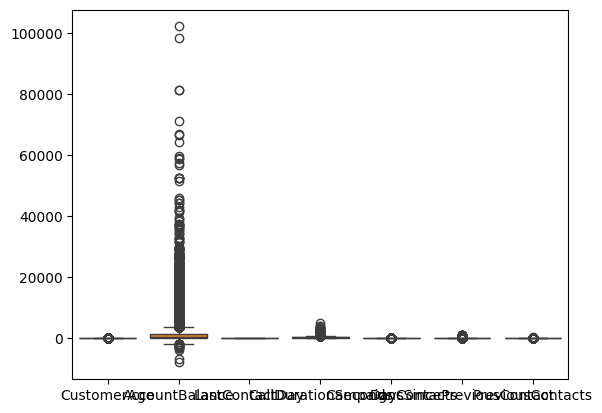

In [64]:
sns.boxplot(df)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CustomerAge               45211 non-null  int64 
 1   JobType                   45211 non-null  object
 2   MaritalStatus             45211 non-null  object
 3   EducationLevel            45211 non-null  object
 4   HasCreditDefault          45211 non-null  object
 5   AccountBalance            45211 non-null  int64 
 6   HasHousingLoan            45211 non-null  object
 7   HasPersonalLoan           45211 non-null  object
 8   ContactType               45211 non-null  object
 9   LastContactDay            45211 non-null  int64 
 10  LastContactMonth          45211 non-null  object
 11  CallDurationSeconds       45211 non-null  int64 
 12  CampaignContacts          45211 non-null  int64 
 13  DaysSincePreviousContact  45211 non-null  int64 
 14  PreviousContacts      

In [66]:
df.columns

Index(['CustomerAge', 'JobType', 'MaritalStatus', 'EducationLevel',
       'HasCreditDefault', 'AccountBalance', 'HasHousingLoan',
       'HasPersonalLoan', 'ContactType', 'LastContactDay', 'LastContactMonth',
       'CallDurationSeconds', 'CampaignContacts', 'DaysSincePreviousContact',
       'PreviousContacts', 'PreviousCampaignOutcome', 'TermDepositSubscribed'],
      dtype='object')

In [67]:
x = df.drop(columns  = "TermDepositSubscribed")
y = df.TermDepositSubscribed

In [68]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state = 42,train_size = 0.8)

In [69]:
num_cols = x.select_dtypes(include = "number").columns
cat_cols = x.select_dtypes(include = "object").columns

In [70]:
cat_cols.nunique()

9

In [71]:
ytrain.value_counts()

TermDepositSubscribed
no     31970
yes     4198
Name: count, dtype: int64

In [72]:
preprocessing = ColumnTransformer(
    transformers = [
        ("scaler",RobustScaler(),num_cols),
        ("encoder",OneHotEncoder(),cat_cols)
    ]
)

In [73]:
main_pipe = Pipeline(
    steps = [
        ("pre",preprocessing),
        ("model",KNeighborsClassifier())
    ]
)

In [74]:
main_pipe.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [75]:
ytrain_pred = main_pipe.predict(xtrain)
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          no       0.93      0.98      0.96     31970
         yes       0.76      0.48      0.59      4198

    accuracy                           0.92     36168
   macro avg       0.85      0.73      0.77     36168
weighted avg       0.91      0.92      0.91     36168



In [77]:
ytest_pred = main_pipe.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7952
         yes       0.60      0.34      0.44      1091

    accuracy                           0.89      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.89      0.88      9043



In [78]:
grid_cv = GridSearchCV(
    estimator = main_pipe,
    param_grid = {
        "model__n_neighbors" : [5,15,20,35,77,100,130,155,212,230],
        "model__metric" : ["manhattan","euclidean"]
    },
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

In [79]:
grid_cv.fit(xtrain,ytrain)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\bthar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan 0.89413296 0.89681492
 0.89546015 0.89584724 0.89501784 0.89385657 0.89316536 0.89291647
 0.89194883 0.89236354]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['manhattan', 'euclidean'], 'model__n_neighbors': [5, 15, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [80]:
ytrain_pred = grid_cv.predict(xtrain)
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          no       0.92      0.98      0.95     31970
         yes       0.69      0.33      0.45      4198

    accuracy                           0.91     36168
   macro avg       0.81      0.66      0.70     36168
weighted avg       0.89      0.91      0.89     36168



In [82]:
ytest_pred = grid_cv.predict(xtest)
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7952
         yes       0.65      0.30      0.41      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043

